# Supporting notebook 1 · Gemma 4 31B, 4-bit QLoRA label-token classifier (member `g31`)

**Role in the solution.** Level-1 text model of the main notebook (stack v10, private LB 0.76000). It produced
`outputs/oof_<run>.npy` (out-of-fold probabilities, 47,817 × 3), `outputs/test_<run>.npy` (mean of the 5 fold models on
the test set, 11,955 × 3) and `outputs/log_<run>.json` for the runs `g31` (seed 42), `g31-s2` (seed 2), `g31-s3` (seed 3), `g31-s4` (seed 4). The main notebook averages these runs
into the member `g31`.


| Setting | Value |
|---|---|
| Base model | `google/gemma-4-31B` (pre-trained, not instruction-tuned), loaded in 4-bit NF4 with double quantisation, bf16 compute |
| Adapter | LoRA r = 16, α = 32, dropout 0.05 on `q/k/v/o/gate/up/down_proj` of the language model (vision/audio towers untouched) |
| Classifier | Prompt ends in `Label:`; loss = class-weighted cross-entropy over the logits of the tokens `0`, `1`, `2` at the last position (fp32) |
| Input | Instruction + `Post: <cleaned post, ≤128 tokens>` + `Label:`, left-padded; only the post is truncated |
| Optimiser | AdamW (fused), lr 5e-5, cosine schedule, 3% warm-up, weight decay 0.01, grad-clip 1.0 |
| Batch | 8 per step × 4 gradient-accumulation steps = 32, length-bucketed |
| Training | 1 epoch per fold, gradient checkpointing; class weights N / (3·n_c) |
| Seeds | 42, 2, 3, 4 (`set_seed(seed + fold)`), averaged into one member |
| Hardware / time | One GPU per fold (H200, A100 80GB, RTX A6000, RTX 6000 Ada); 100–220 min per fold; peak ≈ 21 GiB |


**How to run.** Only the paths in section 0 need changing. With `RUN_TRAINING = False` (default) the notebook reports
the saved runs in `outputs/`. With `RUN_TRAINING = True` it fine-tunes every fold of every seed again with the exact
script that produced them (`train_llm.py`, one call per fold; folds are independent, so they can run on separate GPUs)
and saves each fold's weights.

## 0. Configuration — the only cell to edit

In [1]:
from pathlib import Path
DATA_DIR = Path("../../data")                                         # train.csv, test.csv, sample_submission.csv
CODE_DIR = Path("../../preprocessing_and_helper_files/code")          # common.py, train_llm.py, merge.py
WEIGHTS_DIR = Path("../../preprocessing_and_helper_files/fine_tuned_models/g31_gemma4_31b_qlora_seed42")
OUT_DIR = Path("outputs")                                             # the predictions the main notebook reads
WORK_DIR = Path("work")                                               # per-fold runs + saved weights when re-training
RUN_TRAINING = False                                                  # True: fine-tune all folds again (GPU, hours)
RUNS = {'g31': 42, 'g31-s2': 2, 'g31-s3': 3, 'g31-s4': 4}                                            # run name -> seed
FOLDS = [0, 1, 2, 3, 4]

In [2]:
import json, os, shutil, subprocess, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
sys.path.insert(0, str(CODE_DIR.resolve()))
os.environ["HERWILL_DATA"], os.environ["HERWILL_WORK"] = str(DATA_DIR.resolve()), str(WORK_DIR.resolve())
from common import clean, load, class_weights  # noqa: E402  (preprocessing + pinned folds shared by every model)
mf1 = lambda t, p: f1_score(t, p, average="macro")

## 1. Preprocessing and folds (`common.py`, shared by every model)

`clean()`: Unicode NFKC normalisation, URLs → `<url>`, @handles → `<user>`, whitespace collapsed, empty → `<empty>`.
Emojis and punctuation stay (they carry sarcasm). Rows are sorted by `id` and split with
`StratifiedKFold(5, shuffle=True, random_state=42)`; class weights are N / (3·n_c). The examples below are synthetic.

In [3]:
for s in ["Check this out https://example.com/x   @someone 😂😂", "  এটা   কি   সত্যি?  ", ""]:
    print(repr(s), "->", repr(clean(s)))
d = load()                                   # cleaned texts, labels and folds (cached as JSON under WORK_DIR)
y, folds = d["y"], d["folds"]
print("fold sizes", np.bincount(folds).tolist(), "| class weights", np.round(class_weights(y), 3))

'Check this out https://example.com/x   @someone 😂😂' -> 'Check this out <url> <user> 😂😂'
'  এটা   কি   সত্যি?  ' -> 'এটা কি সত্যি?'
'' -> '<empty>'


fold sizes [9564, 9564, 9563, 9563, 9563] | class weights [0.671 0.878 2.702]


## 2. Model input

Gemma 4 has no sequence-classification class in transformers 5.6, so the classifier is the language-model head
itself: the prompt ends in `Label:` and the logits of the three digit tokens at that position are the class scores.

```
Classify this social-media post (Bangla, English or Banglish). 0 = explicitly toxic or hateful, 1 = subtly toxic
(sarcasm, coded language), 2 = non-toxic or neutral.
Post: <cleaned post>
Label:
```

## 3. Fine-tuning: every fold of every seed

Each call trains on 4 folds, predicts the held-out fold (→ its OOF rows) and the test set, and writes
`WORK_DIR/chpc/runs/<run>/f<k>/`. `merge.py` then assembles `oof_/test_/log_<run>` (test = mean of the 5 fold models).
`--save` also stores the fold's fine-tuned weights in `WORK_DIR/artifacts/<run>/fold<k>/`.

In [4]:
ARGS = ['--model', 'google/gemma-4-31B', '--quant', 'nf4', '--mode', 'labeltok', '--lr', '5e-5', '--maxlen', '128', '--bs', '8', '--accum', '4']
cmds = [[sys.executable, str(CODE_DIR / "train_llm.py"), *ARGS, "--tag", run, "--fold", str(f), "--seed", str(seed), "--save"]
        for run, seed in RUNS.items() for f in FOLDS]
print(len(cmds), "fold runs, e.g.\n ", " ".join(cmds[0][1:]))
if RUN_TRAINING:
    for c in cmds:                           # sequential here; on a cluster each fold ran on its own GPU
        subprocess.run(c, check=True)
    for run in RUNS:
        subprocess.run([sys.executable, str(CODE_DIR / "merge.py"), run], check=True)
        for kind in ("oof", "test"):
            shutil.copy(WORK_DIR / "out" / f"{kind}_{run}.npy", OUT_DIR / f"{kind}_{run}.npy")
        shutil.copy(WORK_DIR / "out" / f"log_{run}.json", OUT_DIR / f"log_{run}.json")

20 fold runs, e.g.
  ../../preprocessing_and_helper_files/code/train_llm.py --model google/gemma-4-31B --quant nf4 --mode labeltok --lr 5e-5 --maxlen 128 --bs 8 --accum 4 --tag g31 --fold 0 --seed 42 --save


## 4. Results of the runs used by the main notebook

In [5]:
rows, member = [], []
for run in RUNS:
    log = json.loads((OUT_DIR / f"log_{run}.json").read_text())
    o = np.load(OUT_DIR / f"oof_{run}.npy"); member.append(o)
    fm = log["fold_macro_f1"]
    rows.append([run, RUNS[run], *[round(fm[str(f)], 4) for f in FOLDS], round(mf1(y, o.argmax(1)), 4),
                 round(sum(log["minutes"].values()) / len(log["minutes"]), 1)])
tab = pd.DataFrame(rows, columns=["run", "seed", *[f"fold {f}" for f in FOLDS], "OOF macro F1", "min / fold"])
print(f"member (mean of {len(member)} runs): OOF macro F1 {mf1(y, np.mean(member, 0).argmax(1)):.4f}")
tab

member (mean of 4 runs): OOF macro F1 0.6247


,run,seed,fold 0,fold 1,fold 2,fold 3,fold 4,OOF macro F1,min / fold
0,g31,42,0.6297,0.6273,0.6232,0.6202,0.6188,0.6239,195.0
1,g31-s2,2,0.6246,0.6262,0.6213,0.6186,0.6163,0.6214,164.1
2,g31-s3,3,0.6196,0.6238,0.6215,0.6172,0.6249,0.6215,199.7
3,g31-s4,4,0.6237,0.6263,0.6191,0.6227,0.6201,0.6224,161.5


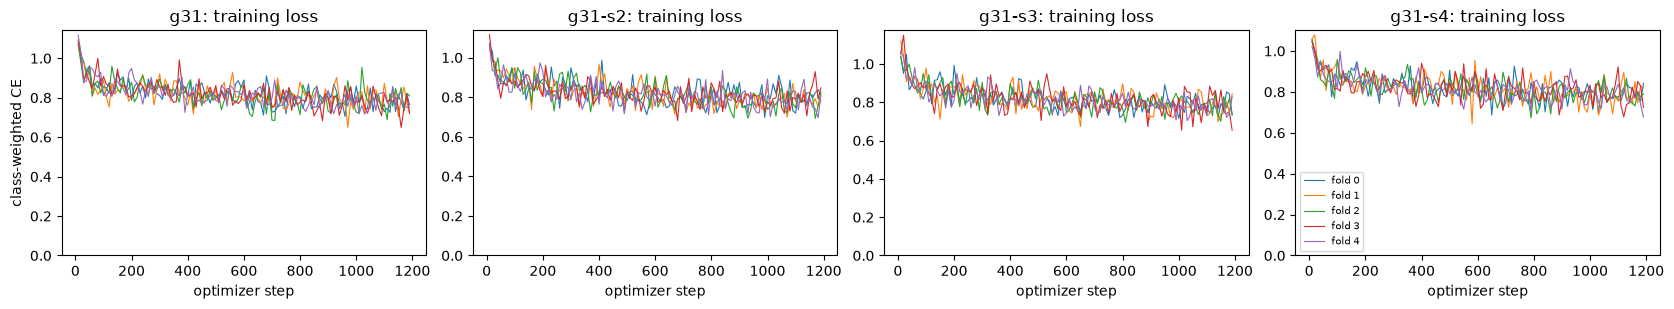

In [6]:
fig, axes = plt.subplots(1, len(RUNS), figsize=(4.2 * len(RUNS), 3.2), squeeze=False)
for ax, run in zip(axes[0], RUNS):
    log = json.loads((OUT_DIR / f"log_{run}.json").read_text())
    div = 4 if (run == "q32") else 1       # q32 seed 42 logged the sum over 4 accumulation steps (see section 2)
    for f, h in log["history"].items():
        pts = [(e["step"], e["loss"] / div) for e in h if "loss" in e]
        if pts:
            ax.plot(*zip(*pts), lw=0.8, label=f"fold {f}")
    ax.set_title(f"{run}: training loss"); ax.set_xlabel("optimizer step"); ax.set_ylim(0, None)
axes[0][0].set_ylabel("class-weighted CE"); axes[0][-1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. Fine-tuned weights: the seed-42 re-run

The original runs above saved predictions only, not weights. To provide the fine-tuned weights, seed 42 was trained
again on 2026-09-28 with the same script, recipe and folds, plus `--save` (run name `g31w`). Its 5 fold models are in
`preprocessing_and_helper_files/fine_tuned_models/g31_gemma4_31b_qlora_seed42/` (Kaggle dataset; see `MODELS.md` there). GPU
training is not bit-deterministic, so the re-run matches the original seed-42 run closely but not exactly; the main
notebook uses the original predictions, which are the ones that were submitted.

In [7]:
orig, rerun = list(RUNS)[0], "g31w"
lo, lr = json.loads((OUT_DIR / f"log_{orig}.json").read_text()), json.loads((OUT_DIR / "rerun_seed42" / f"log_{rerun}.json").read_text())
oo, orr = np.load(OUT_DIR / f"oof_{orig}.npy"), np.load(OUT_DIR / "rerun_seed42" / f"oof_{rerun}.npy")
cmp = pd.DataFrame({"original " + orig: [lo["fold_macro_f1"][str(f)] for f in FOLDS] + [mf1(y, oo.argmax(1))],
                     "re-run " + rerun + " (weights saved)": [lr["fold_macro_f1"][str(f)] for f in FOLDS] + [mf1(y, orr.argmax(1))]},
                   index=[f"fold {f}" for f in FOLDS] + ["OOF"]).round(4)
print(f"OOF prediction agreement original vs re-run: {(oo.argmax(1) == orr.argmax(1)).mean():.2%}")
cmp

OOF prediction agreement original vs re-run: 94.82%


,original g31,re-run g31w (weights saved)
fold 0,0.6297,0.6312
fold 1,0.6273,0.6241
fold 2,0.6232,0.6243
fold 3,0.6202,0.6202
fold 4,0.6188,0.6200
OOF,0.6239,0.6240


In [8]:
for f in FOLDS:
    fd = WEIGHTS_DIR / f"fold{f}"
    files = sorted(p.name for p in fd.iterdir()) if fd.exists() else ["(download the Kaggle dataset, see MODELS.md)"]
    print(f"fold{f}:", ", ".join(files))
print("\nto predict with one fold model:\n  python", CODE_DIR / "predict_from_weights.py", "--weights", WEIGHTS_DIR / "fold0",
      "--texts posts.csv --out probs.npy")

fold0: FILES_ON_KAGGLE.json, adapter_config.json, run_config.json
fold1: FILES_ON_KAGGLE.json, adapter_config.json, run_config.json
fold2: FILES_ON_KAGGLE.json, adapter_config.json, run_config.json
fold3: FILES_ON_KAGGLE.json, adapter_config.json, run_config.json
fold4: FILES_ON_KAGGLE.json, adapter_config.json, run_config.json

to predict with one fold model:
  python ../../preprocessing_and_helper_files/code/predict_from_weights.py --weights ../../preprocessing_and_helper_files/fine_tuned_models/g31_gemma4_31b_qlora_seed42/fold0 --texts posts.csv --out probs.npy
